<a href="https://colab.research.google.com/github/srujana225h8/DataScience-Tasks/blob/main/Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


<Axes: xlabel='loan_status', ylabel='Count'>

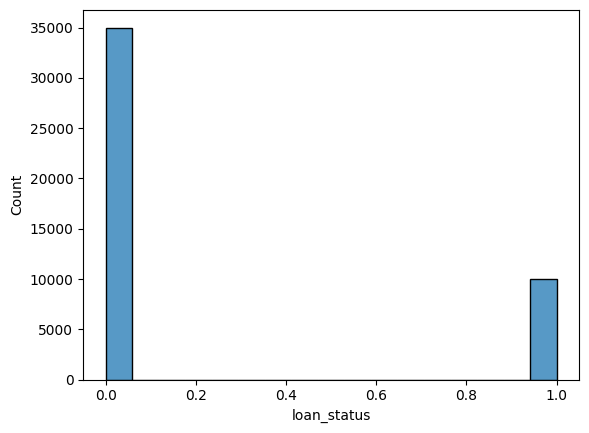

In [ ]:
sns.histplot(x='loan_status', data = df)

In [ ]:
df = df[df['person_age']<=100]
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


<Axes: xlabel='person_gender', ylabel='count'>

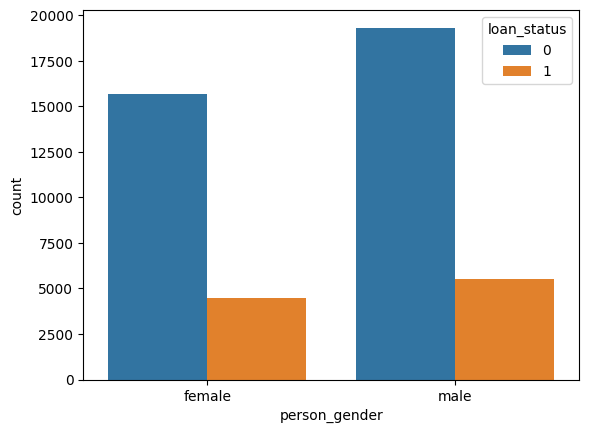

In [ ]:
sns.countplot(x='person_gender', data= df, hue = 'loan_status')

<Axes: xlabel='person_age', ylabel='count'>

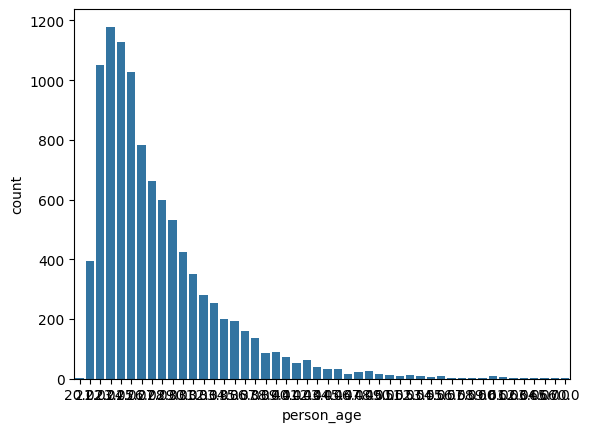

In [ ]:
sns.countplot(x='person_age', data = df[df['loan_status']==1])

<Axes: xlabel='person_education', ylabel='count'>

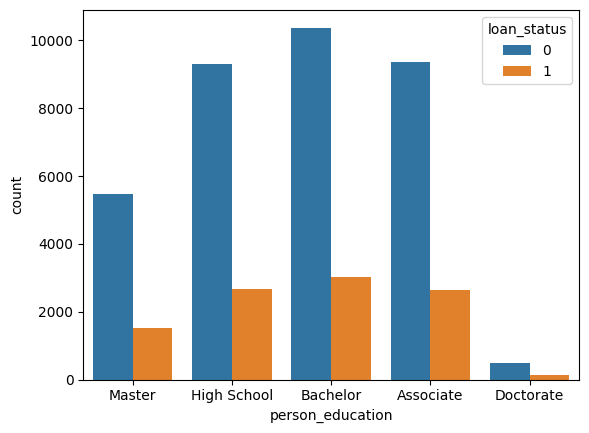

In [ ]:
sns.countplot(x='person_education',data=df, hue='loan_status')

In [ ]:
df.groupby("loan_status")['person_income'].mean()

,person_income
loan_status,
0,85630.263567
1,59886.096900


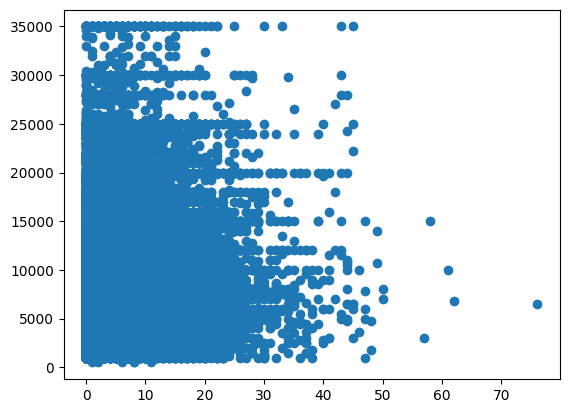

In [ ]:
plt.scatter(df['person_emp_exp'],df['loan_amnt'])

<Axes: xlabel='credit_score', ylabel='Count'>

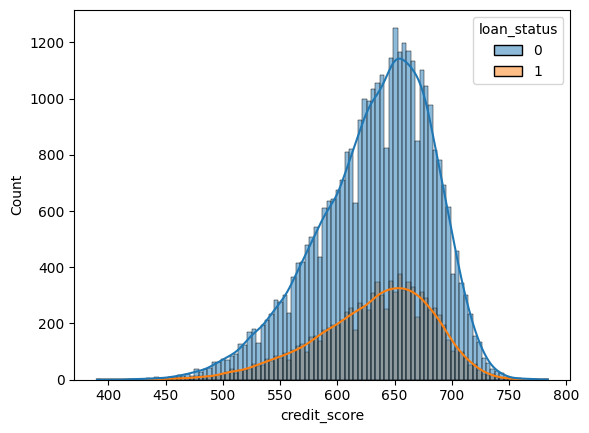

In [ ]:
sns.histplot(x='credit_score', data = df, kde=True, hue="loan_status")

<Axes: >

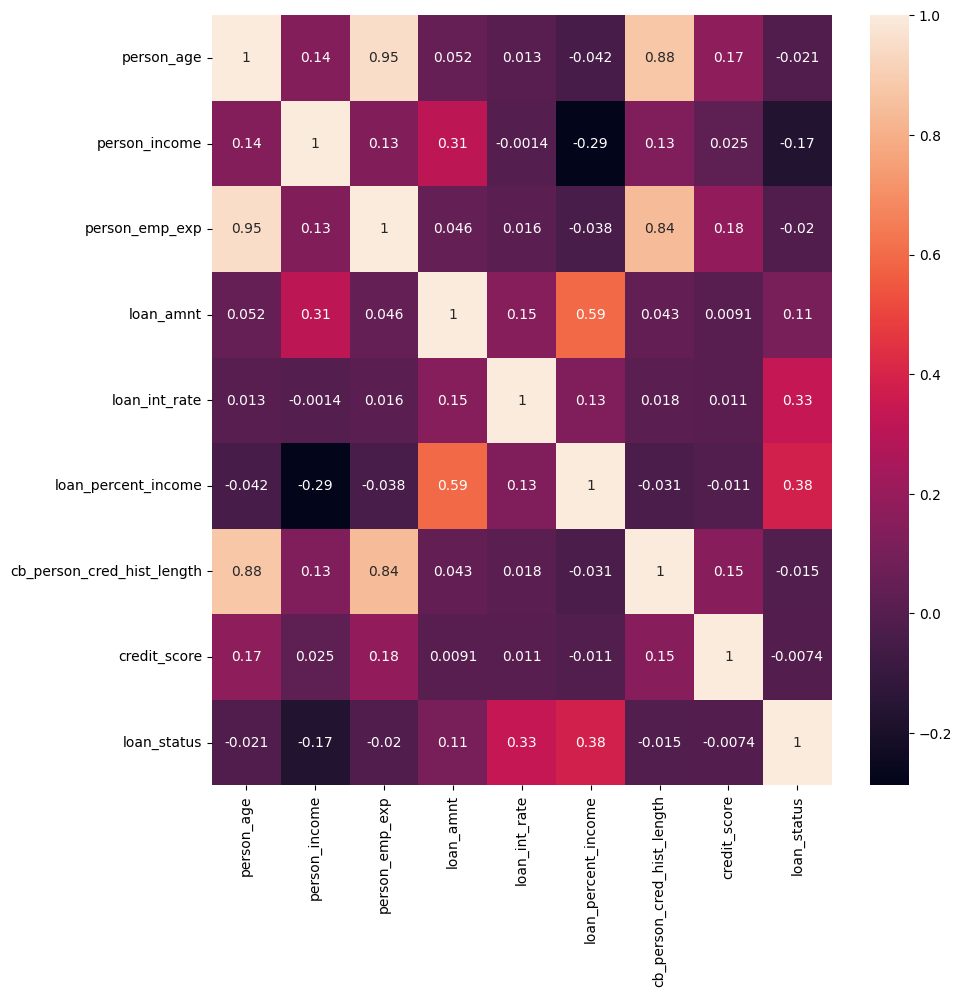

In [ ]:
# getting numerical columns

num_cols = [col for col in df.columns if df[col].dtype != object]

data = df[num_cols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(data, annot=True)

## **Model Training, Evaluation & Tuning**



In [20]:
# Encode the object datatype columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [21]:
# Divide data into input and output

X = df.drop('loan_status', axis=1)
y = df['loan_status']


In [22]:
# dividing the dataframe for training and testing

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
# Scaling the data

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [24]:
# Model training

model = SVC(kernel = 'rbf')
model.fit(Xtrain, ytrain)

SVC()

In [25]:
# Model Prediction

ypred = model.predict(Xtest)
ypred

array([1, 0, 0, ..., 1, 0, 1])

In [26]:
# Model Evaluation

confusion_matrix(ytest, ypred)

array([[10044,   446],
       [  792,  2216]])

In [27]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10490
           1       0.83      0.74      0.78      3008

    accuracy                           0.91     13498
   macro avg       0.88      0.85      0.86     13498
weighted avg       0.91      0.91      0.91     13498



In [28]:
print("Training Eff: ", model.score(Xtrain, ytrain))
print("Testing Eff: ", model.score(Xtest, ytest))

Training Eff:  0.9132560723924432
Testing Eff:  0.9082827085494147


In [30]:
# new inpput prediction

data = df.iloc[0:1,:-1]
data = scaler.transform(data)
pred = model.predict(data)[0]
if pred==0:
  print("Loan is not approved")
else:
  print("Loan is approved")

Loan is approved
